<a href="https://colab.research.google.com/github/cristinarainich/DDCS/blob/main/rvh_termin1only_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1. Loading data frames and initial check of things

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import pylab as pl
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf
from scipy.stats import levene

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
working_path = Path('/content/gdrive/MyDrive/KKNV/rvh')

In [ ]:
!ls /content/gdrive/MyDrive/KKNV/rvh

demographics.csv  extracted_data_termin1.csv


In [ ]:
rvh = pd.read_csv(working_path.joinpath('extracted_data_termin1.csv'), index_col=None)


In [ ]:
rvh.head()

,Subject,Run,Total trials,Initial threshold,Left ET,Left SE,Left SD,Left_accuracy,Is_staircase_completed_left,Right ET,Right SE,Right SD,Right_accuracy,Is_staircase_completed_right
0,DD01,1,10.0,1.0,NaN,NaN,NaN,80.000000,0,NaN,NaN,NaN,55.555556,0
1,DD01,2,75.0,1.0,2.20,0.013628,0.109022,53.061224,1,1.456364,0.019881,0.218690,64.912281,1
2,DD01,3,74.0,1.0,1.62,0.008273,0.115825,67.857143,1,1.904444,0.010702,0.096321,57.446809,1
3,DD01,4,66.0,1.0,1.82,0.013887,0.111098,61.538462,1,1.641250,0.013381,0.214099,63.157895,1
4,DD01,5,68.0,1.0,1.65,0.029611,0.236885,64.406780,1,1.367500,0.007825,0.125193,70.689655,1


In [ ]:
demo = pd.read_csv(working_path.joinpath('demographics.csv'), index_col=None)
# this file contains the demographic information about the participants

In [ ]:
# first, let's work with this file a little
# we will calcualte the age of each participant at the moment of the MRI scan
demo = demo.rename(columns={'nvIQ (perceptial reasoning score)': 'nvIQ'})
demo.loc[demo['Subject'] == 'TD43', 'MRI Scan date'] = '24.08.2026'
demo.loc[demo['Subject'] == 'TD48', 'MRI Scan date'] = '01.10.2026'
demo.loc[demo['Subject'] == 'TD41', 'MRI Scan date'] = '07.10.2026'
demo.loc[demo['Subject'] == 'TD29', 'MRI Scan date'] = '29.04.2026'

demo = demo.dropna(how='all').reset_index(drop=True)
demo['Date of birth'] = pd.to_datetime(demo['Date of birth'], format='%d.%m.%Y', errors='coerce')
demo['MRI Scan date'] = pd.to_datetime(demo['MRI Scan date'], format='%d.%m.%Y', errors='coerce')

demo['Age'] = (demo['MRI Scan date'] - demo['Date of birth']).dt.days / 365.25
demo['Age'] = demo['Age'].round(2)

missing_age = demo[demo['Age'].isna()]
if len(missing_age) != 0:
  print(f"Subjects with missing Age after calculation: {len(missing_age)}")
  print(missing_age[['Subject', 'Date of birth', 'MRI Scan date']])

In [ ]:
# let's save this file additionally
demo.to_csv('demographics_processed.csv', index=False)

In [ ]:
print("Original data shape:", rvh.shape)
rvh_clean = rvh.dropna(subset=['Total trials'])
print(f"Rows removed: {len(rvh) - len(rvh_clean)}")
print(f"Remaining rows: {len(rvh_clean)}")
rvh_clean['Total trials'] = rvh_clean['Total trials'].astype(int)
rvh_analysis = rvh_clean[(rvh_clean['Is_staircase_completed_left'] == 1) &
                         (rvh_clean['Is_staircase_completed_right'] == 1)]
print(f"Rows with incomplete staircases removed: {len(rvh_clean) - len(rvh_analysis)}")
print(f"Remaining rows: {len(rvh_analysis)}")

Original data shape: (417, 14)
Rows removed: 1
Remaining rows: 416
Rows with incomplete staircases removed: 126
Remaining rows: 290


/tmp/ipykernel_4485/493068928.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rvh_clean['Total trials'] = rvh_clean['Total trials'].astype(int)


In [ ]:
rvh_analysis.head()

,Subject,Run,Total trials,Initial threshold,Left ET,Left SE,Left SD,Left_accuracy,Is_staircase_completed_left,Right ET,Right SE,Right SD,Right_accuracy,Is_staircase_completed_right
1,DD01,2,75,1.0,2.2000,0.013628,0.109022,53.061224,1,1.456364,0.019881,0.218690,64.912281,1
2,DD01,3,74,1.0,1.6200,0.008273,0.115825,67.857143,1,1.904444,0.010702,0.096321,57.446809,1
3,DD01,4,66,1.0,1.8200,0.013887,0.111098,61.538462,1,1.641250,0.013381,0.214099,63.157895,1
4,DD01,5,68,1.0,1.6500,0.029611,0.236885,64.406780,1,1.367500,0.007825,0.125193,70.689655,1
6,DD02,2,79,1.0,2.2075,0.052694,0.421553,44.680851,1,1.605000,0.035801,0.286406,57.142857,1


In [ ]:
# Count how many runs each subject has after filtering
runs_per_subject = rvh_analysis.groupby('Subject').size().reset_index(name='Number_of_runs')

print("\nRuns per subject after filtering:")
print(runs_per_subject)

# Show summary statistics
print(f"\nTotal subjects: {len(runs_per_subject)}")
print(f"Average runs per subject: {runs_per_subject['Number_of_runs'].mean():.2f}")
print(f"Min runs: {runs_per_subject['Number_of_runs'].min()}")
print(f"Max runs: {runs_per_subject['Number_of_runs'].max()}")

print(f'People with the initial threshold of 1 (old strategy): {len(rvh_analysis[rvh_analysis['Initial threshold'] == 1.0]['Subject'].unique())}')
print(f'Ids for old strategy: {rvh_analysis[rvh_analysis['Initial threshold'] == 1.0]['Subject'].unique()}')


Runs per subject after filtering:
   Subject  Number_of_runs
0     DD01               4
1     DD02               4
2     DD03               4
3     DD04               3
4     DD05               4
..     ...             ...
89    TD43               3
90    TD44               3
91    TD45               3
92    TD46               3
93    TD47               3

[94 rows x 2 columns]

Total subjects: 94
Average runs per subject: 3.09
Min runs: 1
Max runs: 5
People with the initial threshold of 1 (old strategy): 15
Ids for old strategy: ['DD01' 'DD02' 'DD03' 'DD04' 'DD05' 'DD06' 'DD07' 'TD01' 'TD02' 'TD03'
 'TD04' 'TD05' 'TD06' 'TD07' 'TD39']


In [ ]:
# Show the cleaned data grouped by subject
for subject in rvh_analysis['Subject'].unique():
    subject_data = rvh_analysis[rvh_analysis['Subject'] == subject]
    print(f"\n{subject}: {len(subject_data)} runs")
    print(subject_data[['Subject', 'Run', 'Initial threshold', 'Total trials', 'Left ET', 'Right ET',
                        'Left_accuracy', 'Right_accuracy']].to_string(index=False))


DD01: 4 runs
Subject  Run  Initial threshold  Total trials  Left ET  Right ET  Left_accuracy  Right_accuracy
   DD01    2                1.0            75     2.20  1.456364      53.061224       64.912281
   DD01    3                1.0            74     1.62  1.904444      67.857143       57.446809
   DD01    4                1.0            66     1.82  1.641250      61.538462       63.157895
   DD01    5                1.0            68     1.65  1.367500      64.406780       70.689655

DD02: 4 runs
Subject  Run  Initial threshold  Total trials  Left ET  Right ET  Left_accuracy  Right_accuracy
   DD02    2                1.0            79 2.207500    1.6050      44.680851       57.142857
   DD02    3                1.0            55 2.045000    1.9675      52.500000       46.341463
   DD02    4                1.0            47 1.502500    1.7500      62.500000       45.714286
   DD02    5                1.0            82 2.057333    2.6400      46.000000       44.444444

DD03: 4 run

In [ ]:
len(rvh_analysis['Subject'].unique())

94

In [ ]:
# Explicit list of participants run under the OLD protocol
old_strategy_ids = ['DD01','DD02','DD03','DD04','DD05','DD06','DD07',
                    'TD01','TD02','TD03','TD04','TD05','TD06','TD07']
# NOTE: TD39 deliberately excluded from this list — genuinely low initial
# threshold under the new protocol, not an old-strategy participant.

print("Distribution of Initial Thresholds:")
print(rvh_analysis['Initial threshold'].value_counts().sort_index())

# --- Diagnostic: who would a naive row-level filter catch? ---
flagged = set(rvh_analysis.loc[rvh_analysis['Initial threshold'] == 1, 'Subject'])
print(f"\nSubjects with ANY run at initial threshold = 1: {sorted(flagged)}")
print(f"False positives (flagged but NOT old strategy): "
      f"{sorted(flagged - set(old_strategy_ids))}")

# --- Filter by participant, not by row ---
rvh_analysis_filtered = rvh_analysis[
    ~rvh_analysis['Subject'].isin(old_strategy_ids)
].copy()

print(f"\nOld-strategy participants removed: {len(old_strategy_ids)}")
print(f"Rows removed: {len(rvh_analysis) - len(rvh_analysis_filtered)}")
print(f"Remaining runs: {len(rvh_analysis_filtered)}")
print(f"Subjects remaining: {rvh_analysis_filtered['Subject'].nunique()} "
      f"(from {rvh_analysis['Subject'].nunique()})")

# --- Verify TD39 survived ---
print(f"\nTD39 retained: {'TD39' in rvh_analysis_filtered['Subject'].values}")
print(f"TD39 runs kept: {(rvh_analysis_filtered['Subject'] == 'TD39').sum()}")
print("\nTD39 initial thresholds:")
print(rvh_analysis.loc[rvh_analysis['Subject'] == 'TD39',
                       ['Run','Initial threshold']].to_string(index=False))


Distribution of Initial Thresholds:
Initial threshold
1.00    51
1.20     1
1.30     1
1.45     1
1.50     4
1.54     1
1.60     6
1.70     1
1.75     1
1.76     1
1.80     9
1.83     1
1.85     2
1.88     1
1.90     5
1.96     1
2.00     9
2.10    11
2.15     2
2.20     7
2.25     1
2.30    12
2.40     1
2.48     1
2.50    82
2.51     1
2.60     5
2.63     1
2.65     1
2.70     6
2.80    12
2.83     1
2.90     2
2.95     2
3.00     8
3.10     7
3.11     3
3.20     7
3.25     1
3.30     7
3.50     4
3.60     2
3.70     2
3.80     1
4.00     2
4.05     1
4.10     1
Name: count, dtype: int64

Subjects with ANY run at initial threshold = 1: ['DD01', 'DD02', 'DD03', 'DD04', 'DD05', 'DD06', 'DD07', 'TD01', 'TD02', 'TD03', 'TD04', 'TD05', 'TD06', 'TD07', 'TD39']
False positives (flagged but NOT old strategy): ['TD39']

Old-strategy participants removed: 14
Rows removed: 50
Remaining runs: 240
Subjects remaining: 80 (from 94)

TD39 retained: True
TD39 runs kept: 3

TD39 initial thresholds:
 R

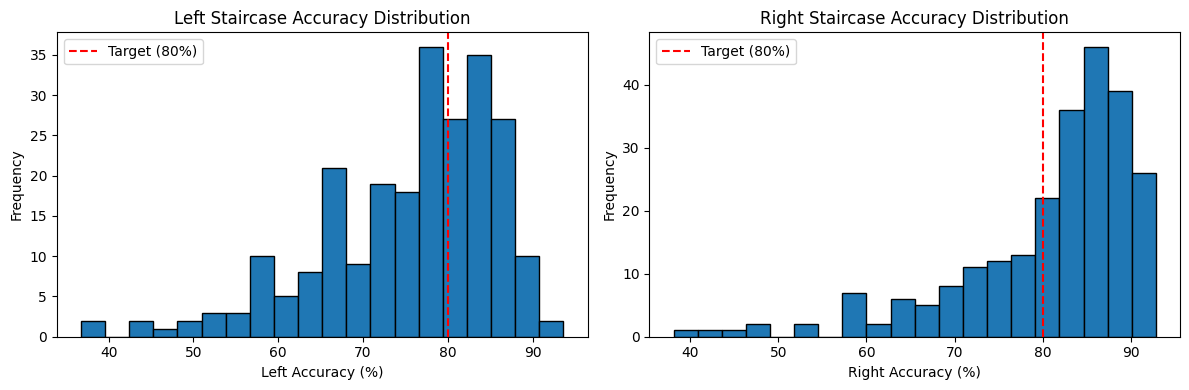


Accuracy Statistics:
Left - Mean: 75.58%, SD: 10.54%
Right - Mean: 80.92%, SD: 10.03%


In [ ]:
import matplotlib.pyplot as plt

# Look at the distribution of accuracy for left and right
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rvh_analysis_filtered['Left_accuracy'], bins=20, edgecolor='black')
axes[0].axvline(x=80, color='red', linestyle='--', label='Target (80%)')
axes[0].set_xlabel('Left Accuracy (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Left Staircase Accuracy Distribution')
axes[0].legend()

axes[1].hist(rvh_analysis_filtered['Right_accuracy'], bins=20, edgecolor='black')
axes[1].axvline(x=80, color='red', linestyle='--', label='Target (80%)')
axes[1].set_xlabel('Right Accuracy (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Right Staircase Accuracy Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("\nAccuracy Statistics:")
print(f"Left - Mean: {rvh_analysis_filtered['Left_accuracy'].mean():.2f}%, SD: {rvh_analysis_filtered['Left_accuracy'].std():.2f}%")
print(f"Right - Mean: {rvh_analysis_filtered['Right_accuracy'].mean():.2f}%, SD: {rvh_analysis_filtered['Right_accuracy'].std():.2f}%")


Strateges for handling multiple runs situation: 1. select the runs close 80%; 2. weighted rund depending on how close they are to 80%; 3. average runs with accuracy 70-90%.

# Part II: preparation for the analysis


Step 1. What will happen if we filter based on the accuracy - what are we losing and how does it change the results.

In [ ]:
print(f'Number of data points as it is: {rvh_analysis_filtered.shape[0]}')
print(f'Number of points left if we remove anything outside 70 < x < 90: {rvh_analysis_filtered[(rvh_analysis_filtered['Left_accuracy'] >= 70) & (rvh_analysis_filtered['Right_accuracy'] >= 70) &
                      (rvh_analysis_filtered['Left_accuracy'] <= 90) & (rvh_analysis_filtered['Right_accuracy'] <= 90)].shape[0]}')
print(f'Number of points left if we remove anything below 65: {rvh_analysis_filtered[(rvh_analysis_filtered['Left_accuracy'] >= 65) & (rvh_analysis_filtered['Right_accuracy'] >= 65)].shape[0]}')

Number of data points as it is: 240
Number of points left if we remove anything outside 70 < x < 90: 137
Number of points left if we remove anything below 65: 198


In [ ]:
rvh_analysis_filtered[(rvh_analysis_filtered['Left_accuracy'] >= 70) & (rvh_analysis_filtered['Right_accuracy'] >= 70) &
                      (rvh_analysis_filtered['Left_accuracy'] <= 90) & (rvh_analysis_filtered['Right_accuracy'] <= 90)]

,Subject,Run,Total trials,Initial threshold,Left ET,Left SE,Left SD,Left_accuracy,Is_staircase_completed_left,Right ET,Right SE,Right SD,Right_accuracy,Is_staircase_completed_right
42,DD08,5,78,2.7,2.970000,0.017678,0.141421,77.777778,1,2.638182,0.010983,0.120815,80.821918,1
44,DD09,2,85,1.8,2.280000,0.028536,0.228286,78.082192,1,2.156667,0.008670,0.104040,77.215190,1
45,DD09,3,70,1.8,1.777500,0.007727,0.061818,79.629630,1,1.462222,0.010210,0.091894,86.153846,1
46,DD09,4,111,1.8,1.824762,0.006591,0.138406,78.947368,1,1.285000,0.020255,0.162041,86.315789,1
59,DD12,4,79,3.0,3.275556,0.020780,0.187023,72.727273,1,3.525000,0.014684,0.117473,72.340426,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,TD45,2,99,2.5,1.880000,0.025774,0.206190,88.372093,1,2.340000,0.008949,0.116333,81.609195,1
407,TD45,3,99,2.0,1.415000,0.014623,0.116986,85.714286,1,2.135385,0.008752,0.113770,80.000000,1
408,TD45,4,87,1.8,1.165000,0.009797,0.078376,85.365854,1,2.007273,0.015153,0.166679,75.000000,1
411,TD46,3,95,2.0,1.768889,0.026600,0.239397,86.363636,1,1.535000,0.024955,0.199643,87.500000,1


In [ ]:
rvh_analysis_filtered.head()

,Subject,Run,Total trials,Initial threshold,Left ET,Left SE,Left SD,Left_accuracy,Is_staircase_completed_left,Right ET,Right SE,Right SD,Right_accuracy,Is_staircase_completed_right
39,DD08,2,66,1.9,2.840000,0.017436,0.261534,52.542373,1,2.512500,0.013225,0.105796,65.454545,1
40,DD08,3,90,2.7,3.287692,0.023345,0.303484,68.000000,1,2.315000,0.038423,0.307385,84.337349,1
42,DD08,5,78,2.7,2.970000,0.017678,0.141421,77.777778,1,2.638182,0.010983,0.120815,80.821918,1
44,DD09,2,85,1.8,2.280000,0.028536,0.228286,78.082192,1,2.156667,0.008670,0.104040,77.215190,1
45,DD09,3,70,1.8,1.777500,0.007727,0.061818,79.629630,1,1.462222,0.010210,0.091894,86.153846,1


In [ ]:
rvh_analysis_filtered['Group'] = rvh_analysis_filtered['Subject'].str[:2]

STEP 2. Preparing the dataframe for easier further analysis

In [ ]:
# reconstruct the data so that it would be easy to use it in LMMs and for the tests
rvh_long = pd.DataFrame()
left_data = rvh_analysis_filtered[['Subject', 'Group', 'Run', 'Total trials',
                          'Left ET', 'Left SE', 'Left SD', 'Left_accuracy']].copy()
left_data['Visual_Field'] = 'Left'
left_data['Threshold'] = left_data['Left ET']
left_data['Threshold_SE'] = left_data['Left SE']
left_data['Threshold_SD'] = left_data['Left SD']
left_data['Accuracy'] = left_data['Left_accuracy']

right_data = rvh_analysis_filtered[['Subject', 'Group', 'Run', 'Total trials',
                           'Right ET', 'Right SE', 'Right SD', 'Right_accuracy']].copy()
right_data['Visual_Field'] = 'Right'
right_data['Threshold'] = right_data['Right ET']
right_data['Threshold_SE'] = right_data['Right SE']
right_data['Threshold_SD'] = right_data['Right SD']
right_data['Accuracy'] = right_data['Right_accuracy']

rvh_long = pd.concat([
    left_data[['Subject', 'Group', 'Run', 'Visual_Field', 'Threshold',
               'Threshold_SE', 'Threshold_SD', 'Accuracy', 'Total trials']],
    right_data[['Subject', 'Group', 'Run', 'Visual_Field', 'Threshold',
                'Threshold_SE', 'Threshold_SD', 'Accuracy', 'Total trials']]
], ignore_index=True)

rvh_long['Accuracy_centered'] = rvh_long['Accuracy'] - 80

print("Data restructured to long format:")
print(rvh_long.head(10))
print(f"\nTotal observations: {len(rvh_long)}")
print(f"Subjects: {rvh_long['Subject'].nunique()}")
print(f"TD subjects: {len(rvh_long[rvh_long['Group']=='TD']['Subject'].unique())}")
print(f"DD subjects: {len(rvh_long[rvh_long['Group']=='DD']['Subject'].unique())}")


Data restructured to long format:
  Subject Group  Run Visual_Field  Threshold  Threshold_SE  Threshold_SD  \
0    DD08    DD    2         Left   2.840000      0.017436      0.261534   
1    DD08    DD    3         Left   3.287692      0.023345      0.303484   
2    DD08    DD    5         Left   2.970000      0.017678      0.141421   
3    DD09    DD    2         Left   2.280000      0.028536      0.228286   
4    DD09    DD    3         Left   1.777500      0.007727      0.061818   
5    DD09    DD    4         Left   1.824762      0.006591      0.138406   
6    DD10    DD    3         Left   3.443333      0.016428      0.492848   
7    DD10    DD    4         Left   4.161053      0.015838      0.300923   
8    DD10    DD    5         Left   4.135000      0.016177      0.194118   
9    DD11    DD    3         Left   4.326667      0.020801      0.312013   

    Accuracy  Total trials  Accuracy_centered  
0  52.542373            66         -27.457627  
1  68.000000            90       

In [ ]:
# now let's combine this resulting rvh_long table with the demographics information
demo.head()

,Subject,Date of birth,MRI Scan date,Sex,Age,Education,IQ,nvIQ,vIQ,Comment
0,DD01,1982-03-18,2024-02-17,m,41.92,Hauptschule,84.0,106.0,81.0,NaN
1,DD02,1995-12-02,2024-02-19,m,28.22,Realschulabschluss,97.0,100.0,113.0,NaN
2,DD03,2000-11-04,2024-02-21,f,23.30,Abitur,100.0,106.0,105.0,NaN
3,DD04,1997-06-10,2024-03-22,m,26.78,Abitur,97.0,94.0,109.0,NaN
4,DD05,2001-06-14,2024-03-25,m,22.78,Fachhochschulreife,107.0,129.0,96.0,NaN


In [ ]:
demo_cols = ['Subject', 'Sex', 'Age', 'Education', 'IQ', 'nvIQ', 'vIQ']
rvh_long_full = rvh_long.merge(demo[demo_cols], on='Subject', how='left')

# Check for unmatched subjects (present in one dataset but not the other)
unmatched_in_rvh = set(rvh_long['Subject']) - set(demo['Subject'])
unmatched_in_demo = set(demo['Subject']) - set(rvh_long['Subject'])

print(f"\nSubjects in rvh_long but NOT in demographics: {unmatched_in_rvh}")
print(f"Subjects in demographics but NOT in rvh_long: {unmatched_in_demo}")

print(f"\nFinal merged shape: {rvh_long_full.shape}")
print(rvh_long_full.head())


Subjects in rvh_long but NOT in demographics: set()
Subjects in demographics but NOT in rvh_long: {'TD06', 'DD05', 'TD01', 'DD03', 'DD02', 'DD07', 'TD02', 'TD48', 'TD11', 'TD04', 'DD06', 'TD03', 'DD01', 'TD05', 'DD04', 'TD07'}

Final merged shape: (480, 16)
  Subject Group  Run Visual_Field  Threshold  Threshold_SE  Threshold_SD  \
0    DD08    DD    2         Left   2.840000      0.017436      0.261534   
1    DD08    DD    3         Left   3.287692      0.023345      0.303484   
2    DD08    DD    5         Left   2.970000      0.017678      0.141421   
3    DD09    DD    2         Left   2.280000      0.028536      0.228286   
4    DD09    DD    3         Left   1.777500      0.007727      0.061818   

    Accuracy  Total trials  Accuracy_centered Sex    Age         Education  \
0  52.542373            66         -27.457627   m  32.48  Hochschulstudium   
1  68.000000            90         -12.000000   m  32.48  Hochschulstudium   
2  77.777778            78          -2.222222   m 

# Part III: Analysis

In [ ]:
# ================================================================
# STEP 1: Descriptive statistics
# ================================================================
print("="*80)
print("STEP 1: DESCRIPTIVE STATISTICS")
print("="*80)

desc = rvh_long_full.groupby(['Group', 'Visual_Field'])['Threshold'].describe()
print(desc)

print("\nAccuracy distribution:")
print(rvh_long_full.groupby('Group')['Accuracy'].describe())

runs_per_subject = rvh_long_full.groupby(['Subject', 'Group']).size().reset_index(name='N_observations')
runs_per_subject['N_runs'] = runs_per_subject['N_observations'] / 2
print("\nObservations per subject:")
print(runs_per_subject.groupby('Group')['N_runs'].describe())

STEP 1: DESCRIPTIVE STATISTICS
                    count      mean       std       min       25%       50%  \
Group Visual_Field                                                            
DD    Left          122.0  2.865661  0.778624  1.210769  2.275962  2.873750   
      Right         122.0  2.467623  0.883872  0.605000  1.786250  2.483000   
TD    Left          118.0  2.343544  0.708608  0.865000  1.942976  2.272581   
      Right         118.0  2.099171  0.620746  0.432500  1.630000  2.124314   

                         75%       max  
Group Visual_Field                      
DD    Left          3.342727  4.934483  
      Right         3.071364  4.705000  
TD    Left          2.864561  3.838095  
      Right         2.482500  3.850000  

Accuracy distribution:
       count       mean        std        min        25%        50%  \
Group                                                                 
DD     244.0  76.236939  11.779913  36.734694  69.110577  78.947368   
TD     236.

In [ ]:
# ================================================================
# STEP 2 (NEW): GROUP COMPARABILITY — DEMOGRAPHIC CHARACTERISTICS
# ================================================================
print("\n" + "="*80)
print("STEP 2: GROUP COMPARABILITY — DEMOGRAPHICS (Age, IQ, nvIQ, vIQ, Sex)")
print("="*80)

# One row per subject (demographics don't vary across runs)
subject_demo = rvh_long_full.drop_duplicates(subset='Subject')[
    ['Subject', 'Group', 'Sex', 'Age', 'IQ', 'nvIQ', 'vIQ']
]

n_total = subject_demo.shape[0]
n_with_age = subject_demo['Age'].notna().sum()
print(f"\nTotal subjects: {n_total} | With valid Age: {n_with_age}")

continuous_vars = ['Age', 'IQ', 'nvIQ', 'vIQ']

# --- Normality check per variable per group (determines which test to trust) ---
print("\n--- Shapiro-Wilk normality check (per Group) ---")
for var in continuous_vars:
    for group in ['DD', 'TD']:
        vals = subject_demo.loc[subject_demo['Group'] == group, var].dropna()
        if len(vals) >= 3:
            stat, p = shapiro(vals)
            flag = "NOT normal" if p < 0.05 else "normal"
            print(f"{var:6s} - {group}: W={stat:.3f}, p={p:.4f}, n={len(vals):3d} → {flag}")

# --- Group comparison: Welch's t-test AND Mann-Whitney (report whichever fits normality) ---
print("\n--- DD vs TD comparison on continuous variables ---")
demo_results = []
for var in continuous_vars:
    dd_vals = subject_demo.loc[subject_demo['Group'] == 'DD', var].dropna()
    td_vals = subject_demo.loc[subject_demo['Group'] == 'TD', var].dropna()

    t_stat, t_p = ttest_ind(dd_vals, td_vals, equal_var=False)  # Welch's, safer default
    u_stat, u_p = mannwhitneyu(dd_vals, td_vals)

    demo_results.append({
        'Variable': var,
        'DD_mean': round(dd_vals.mean(), 2), 'DD_SD': round(dd_vals.std(), 2), 'DD_n': len(dd_vals),
        'TD_mean': round(td_vals.mean(), 2), 'TD_SD': round(td_vals.std(), 2), 'TD_n': len(td_vals),
        'Welch_t': round(t_stat, 3), 'Welch_p': round(t_p, 4),
        'MannWhitney_U': round(u_stat, 1), 'MannWhitney_p': round(u_p, 4)
    })

demo_comparison = pd.DataFrame(demo_results)
print(demo_comparison.to_string(index=False))

# --- Sex distribution: chi-square (or Fisher's exact if any expected cell < 5) ---
print("\n--- Sex distribution ---")
sex_ct = pd.crosstab(subject_demo['Group'], subject_demo['Sex'])
print(sex_ct)

chi2, p_chi2, dof, expected = chi2_contingency(sex_ct)
min_expected = expected.min()
print(f"\nChi-square test: χ²={chi2:.3f}, dof={dof}, p={p_chi2:.4f}")

if min_expected < 5 and sex_ct.shape == (2, 2):
    odds_ratio, p_fisher = fisher_exact(sex_ct)
    print(f"⚠ Minimum expected cell count = {min_expected:.1f} (<5) → Fisher's exact test recommended instead:")
    print(f"Fisher's exact test: OR={odds_ratio:.3f}, p={p_fisher:.4f}")


STEP 2: GROUP COMPARABILITY — DEMOGRAPHICS (Age, IQ, nvIQ, vIQ, Sex)

Total subjects: 80 | With valid Age: 80

--- Shapiro-Wilk normality check (per Group) ---
Age    - DD: W=0.877, p=0.0004, n= 41 → NOT normal
Age    - TD: W=0.879, p=0.0006, n= 39 → NOT normal
IQ     - DD: W=0.965, p=0.2694, n= 38 → normal
IQ     - TD: W=0.938, p=0.0496, n= 35 → NOT normal
nvIQ   - DD: W=0.989, p=0.9634, n= 39 → normal
nvIQ   - TD: W=0.952, p=0.1281, n= 35 → normal
vIQ    - DD: W=0.967, p=0.3115, n= 38 → normal
vIQ    - TD: W=0.960, p=0.2253, n= 35 → normal

--- DD vs TD comparison on continuous variables ---
Variable  DD_mean  DD_SD  DD_n  TD_mean  TD_SD  TD_n  Welch_t  Welch_p  MannWhitney_U  MannWhitney_p
     Age    26.41   6.97    41    30.03   8.61    39   -2.062   0.0427          585.5         0.0399
      IQ   102.61  11.49    38   109.60  13.30    35   -2.395   0.0194          456.5         0.0215
    nvIQ   108.54  11.96    39   108.63  13.67    35   -0.030   0.9761          694.5         0

/tmp/ipykernel_4485/4212816286.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subject_demo, x='Group', y='Age', ax=axes[1],


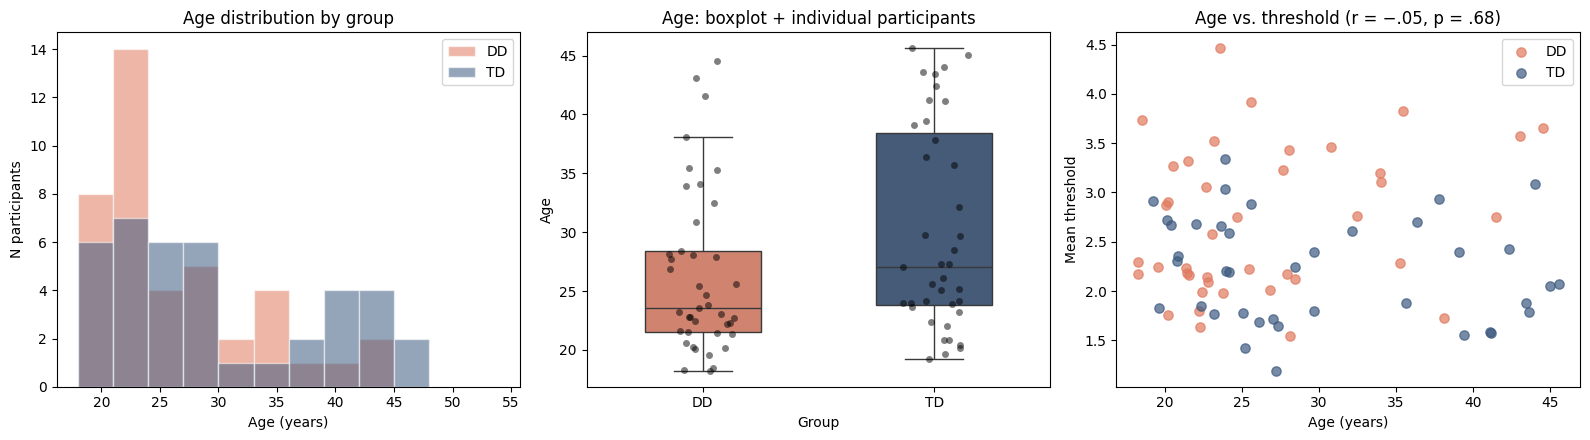

Subject Group   Age
   TD24    TD 45.60
   TD38    TD 45.02
   DD18    DD 44.55
   TD10    TD 44.02
   TD43    TD 43.64
   TD33    TD 43.46
   DD47    DD 43.09
   TD14    TD 42.37
   DD20    DD 41.52
   TD22    TD 41.18

Age ranges:
         min    max  median   mean   std
Group                                   
DD     18.24  44.55   23.58  26.41  6.97
TD     19.25  45.60   27.02  30.03  8.61


In [ ]:
# exploring age here
subject_demo = rvh_long_full.drop_duplicates(subset='Subject')[['Subject','Group','Age','IQ','nvIQ','vIQ','Sex']]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Overlapping histograms
for g, c in [('DD','#E07A5F'), ('TD','#3D5A80')]:
    axes[0].hist(subject_demo.loc[subject_demo.Group==g,'Age'],
                 bins=np.arange(18, 56, 3), alpha=0.55, label=g, color=c, edgecolor='white')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('N participants')
axes[0].set_title('Age distribution by group'); axes[0].legend()

# Boxplot + individual points
sns.boxplot(data=subject_demo, x='Group', y='Age', ax=axes[1],
            palette={'DD':'#E07A5F','TD':'#3D5A80'}, width=0.5, showfliers=False)
sns.stripplot(data=subject_demo, x='Group', y='Age', ax=axes[1],
              color='black', alpha=0.5, size=5, jitter=0.15)
axes[1].set_title('Age: boxplot + individual participants')

# Age vs Threshold — the key panel
subj_thr = rvh_long_full.groupby(['Subject','Group'])[['Threshold','Age']].mean().reset_index()
for g, c in [('DD','#E07A5F'), ('TD','#3D5A80')]:
    s = subj_thr[subj_thr.Group==g]
    axes[2].scatter(s['Age'], s['Threshold'], color=c, alpha=0.7, s=45, label=g)
axes[2].set_xlabel('Age (years)'); axes[2].set_ylabel('Mean threshold')
axes[2].set_title('Age vs. threshold (r = −.05, p = .68)'); axes[2].legend()

plt.tight_layout(); plt.savefig('age_diagnostics.png', dpi=300); plt.show()

# Who exactly is in the upper tail?
print(subject_demo.nlargest(10, 'Age')[['Subject','Group','Age']].to_string(index=False))
print("\nAge ranges:")
print(subject_demo.groupby('Group')['Age'].agg(['min','max','median','mean','std']).round(2))

In [ ]:
# Sensitivity only — restrict to overlapping age range
lo = subject_demo.groupby('Group')['Age'].min().max()
hi = subject_demo.groupby('Group')['Age'].max().min()
matched_ids = subject_demo.loc[subject_demo.Age.between(lo, hi), 'Subject']
rvh_matched = rvh_long_full[rvh_long_full.Subject.isin(matched_ids)]

print(f"Age-matched range: {lo:.1f}–{hi:.1f} yrs | N subjects: {rvh_matched.Subject.nunique()} (from {subject_demo.shape[0]})")

m_matched = smf.mixedlm("Threshold ~ Group * Visual_Field + Run",
                        data=rvh_matched, groups=rvh_matched["Subject"]).fit()
print(m_matched.summary())


Age-matched range: 19.2–44.5 yrs | N subjects: 75 (from 80)
                   Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        Threshold
No. Observations:        450            Method:                    REML     
No. Groups:              75             Scale:                     0.1876   
Min. group size:         4              Log-Likelihood:            -368.6636
Max. group size:         8              Converged:                 Yes      
Mean group size:         6.0                                                
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          3.335    0.136 24.607 0.000  3.069  3.601
Group[T.TD]                       -0.548    0.160 -3.413 0.001 -0.862 -0.233
Visual_Field[T.Right]             -0

In [ ]:
for cov in ['IQ', 'nvIQ', 'vIQ']:
    rvh_long_full[f'{cov}_c'] = rvh_long_full[cov] - rvh_long_full[cov].mean()
    m = smf.mixedlm(f"Threshold ~ Group * Visual_Field + Run + {cov}_c",
                    data=rvh_long_full.dropna(subset=[cov]),
                    groups=rvh_long_full.dropna(subset=[cov])["Subject"]).fit()
    print(f"\n--- + {cov}_centered (N={int(m.nobs)}) ---")
    print(f"Group β={m.params['Group[T.TD]']:.3f}, p={m.pvalues['Group[T.TD]']:.4f}")
    print(f"VF    β={m.params['Visual_Field[T.Right]']:.3f}, p={m.pvalues['Visual_Field[T.Right]']:.4f}")
    print(f"Inter β={m.params['Group[T.TD]:Visual_Field[T.Right]']:.3f}, p={m.pvalues['Group[T.TD]:Visual_Field[T.Right]']:.4f}")
    print(f"{cov}  β={m.params[f'{cov}_c']:.4f}, p={m.pvalues[f'{cov}_c']:.4f}")



--- + IQ_centered (N=440) ---
Group β=-0.501, p=0.0021
VF    β=-0.381, p=0.0000
Inter β=0.118, p=0.1539
IQ  β=-0.0051, p=0.4127

--- + nvIQ_centered (N=444) ---
Group β=-0.579, p=0.0003
VF    β=-0.378, p=0.0000
Inter β=0.115, p=0.1626
nvIQ  β=-0.0107, p=0.0796

--- + vIQ_centered (N=440) ---
Group β=-0.594, p=0.0003
VF    β=-0.381, p=0.0000
Inter β=0.118, p=0.1539
vIQ  β=0.0079, p=0.2694


In [ ]:
# ================================================================
# STEP 3: Check for outliers
# ================================================================
print("\n" + "="*80)
print("STEP 3: OUTLIER CHECK")
print("="*80)

threshold_mean = rvh_long_full['Threshold'].mean()
threshold_sd = rvh_long_full['Threshold'].std()
rvh_long_full['is_outlier'] = abs(rvh_long_full['Threshold'] - threshold_mean) > 3 * threshold_sd

print(f"\nOutliers detected (pooled 3SD rule): {rvh_long_full['is_outlier'].sum()} / {len(rvh_long_full)}")

# Also break outlier count down by Group (pooled 3SD can miss group-specific extremes)
print("\nOutliers by Group:")
print(rvh_long_full.groupby('Group')['is_outlier'].sum())


STEP 3: OUTLIER CHECK

Outliers detected (pooled 3SD rule): 1 / 480

Outliers by Group:
Group
DD    1
TD    0
Name: is_outlier, dtype: int64


In [ ]:
# removing the outlier
print(rvh_long_full.shape[0])
rvh_long_full = rvh_long_full[rvh_long_full['is_outlier'] == False]
print(rvh_long_full.shape[0])

480
479



STEP 4: Post check of data
Correlation b/w age and threshold: Pearson r = -0.046, p = 0.6822
Correlation b/w age and threshold: Spearman rho = -0.073, p = 0.5206


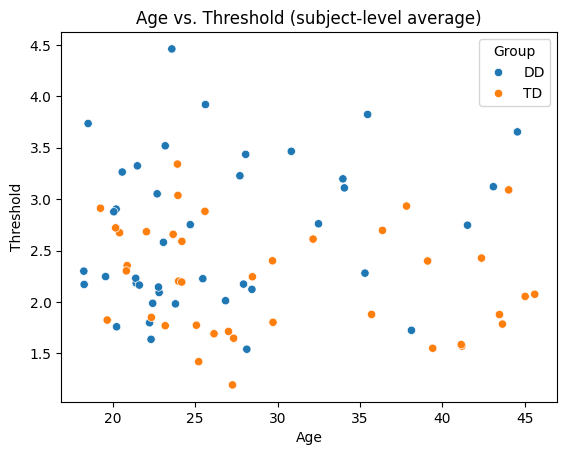

In [ ]:
# ================================================================
# STEP 4: Post check of data
# ================================================================
# there are no outliers, but the age significantly differs between the groups
# let's see whether age actually relates to threshold at all
print("\n" + "="*80)
print("STEP 4: Post check of data")
print("="*80)
subject_level = rvh_long_full.groupby(['Subject', 'Group'])[['Threshold', 'Age']].mean().reset_index()

r, p = pearsonr(subject_level['Age'], subject_level['Threshold'])
rho, p_rho = spearmanr(subject_level['Age'], subject_level['Threshold'])
print(f"Correlation b/w age and threshold: Pearson r = {r:.3f}, p = {p:.4f}")
print(f"Correlation b/w age and threshold: Spearman rho = {rho:.3f}, p = {p_rho:.4f}")

sns.scatterplot(data=subject_level, x='Age', y='Threshold', hue='Group')
plt.title('Age vs. Threshold (subject-level average)')
plt.show()

# Add centralised age and log transformed threshold to the dataset
rvh_long_full['Age_centered'] = rvh_long_full['Age'] - rvh_long_full['Age'].mean()
rvh_long_full['log_Threshold'] = np.log(rvh_long_full['Threshold'])

# Given than there is a difference in age between groups but there is no correlation between age and threshold
# we won't include it in a primary model but run a sensitivity check later

In [ ]:
# ================================================================
# STEP 5: Replication check - Rima et al. 2020
# ================================================================
print("\n" + "="*80)
print("STEP 5: Replication check - Rima et al. 2020")
print("Wilcoxon's test comparison b/w LVH and RVH")
print("="*80)

# Method 1: Average across runs (not exactly as done in Rima et al. 2020,
# but the simplest, most literature-comparable approach)
subject_averages = rvh_long_full.groupby(['Subject', 'Group', 'Visual_Field'])['Threshold'].mean().reset_index()
print("WILCOXON TESTS USING AVERAGE RUN METHOD")

for group in ['DD', 'TD']:
    group_data = subject_averages[subject_averages['Group'] == group]
    pivot = group_data.pivot(index='Subject', columns='Visual_Field', values='Threshold')

    stat, p = stats.wilcoxon(pivot['Left'], pivot['Right'])
    mean_diff = (pivot['Left'] - pivot['Right']).mean()

    print(f"\n{group} Group - Wilcoxon Signed-Rank Test:")
    print(f"  Left - Right mean difference: {mean_diff:.3f}")
    print(f"  Test statistic: {stat:.1f}, p-value: {p:.4f}")

    if p < 0.05:
        direction = "RIGHT" if mean_diff > 0 else "LEFT"
        print(f"  → Significant {direction} hemifield advantage")
    else:
        print(f"  → No significant hemifield difference")


# Method 2: Using "best run" (closest to 80% accuracy) — closer to original study's logic
def get_best_run_per_subject(df):
    best_runs = []
    for subject in df['Subject'].unique():
        subj_data = df[df['Subject'] == subject]
        subj_data_wide = subj_data.pivot_table(
            values='Accuracy',
            index=['Subject', 'Group', 'Run'],
            columns='Visual_Field'
        ).reset_index()

        subj_data_wide['avg_accuracy'] = (subj_data_wide['Left'] + subj_data_wide['Right']) / 2
        subj_data_wide['distance_from_80'] = abs(subj_data_wide['avg_accuracy'] - 80)

        best_run_idx = subj_data_wide['distance_from_80'].idxmin()
        best_run_num = subj_data_wide.loc[best_run_idx, 'Run']

        best_run_data = subj_data[subj_data['Run'] == best_run_num]
        best_runs.append(best_run_data)

    return pd.concat(best_runs, ignore_index=True)

best_runs_df = get_best_run_per_subject(rvh_long_full)

print('')
print("WILCOXON TESTS USING 'BEST RUN' METHOD (closer to original study's approach)")
best_run_averages = best_runs_df.groupby(['Subject', 'Group', 'Visual_Field'])['Threshold'].mean().reset_index()

for group in ['DD', 'TD']:
    group_data = best_run_averages[best_run_averages['Group'] == group]
    pivot = group_data.pivot(index='Subject', columns='Visual_Field', values='Threshold')

    stat, p = stats.wilcoxon(pivot['Left'], pivot['Right'])
    mean_diff = (pivot['Left'] - pivot['Right']).mean()

    print(f"\n{group} Group - Wilcoxon Signed-Rank Test:")
    print(f"  Left - Right mean difference: {mean_diff:.3f}")
    print(f"  Test statistic: {stat:.1f}, p-value: {p:.4f}")

    if p < 0.05:
        direction = "RIGHT" if mean_diff > 0 else "LEFT"
        print(f"  → Significant {direction} hemifield advantage")
    else:
        print(f"  → No significant hemifield difference")



STEP 5: Replication check - Rima et al. 2020
Wilcoxon's test comparison b/w LVH and RVH
WILCOXON TESTS USING AVERAGE RUN METHOD

DD Group - Wilcoxon Signed-Rank Test:
  Left - Right mean difference: 0.405
  Test statistic: 103.0, p-value: 0.0000
  → Significant RIGHT hemifield advantage

TD Group - Wilcoxon Signed-Rank Test:
  Left - Right mean difference: 0.253
  Test statistic: 183.0, p-value: 0.0032
  → Significant RIGHT hemifield advantage

WILCOXON TESTS USING 'BEST RUN' METHOD (closer to original study's approach)

DD Group - Wilcoxon Signed-Rank Test:
  Left - Right mean difference: 0.457
  Test statistic: 118.0, p-value: 0.0000
  → Significant RIGHT hemifield advantage

TD Group - Wilcoxon Signed-Rank Test:
  Left - Right mean difference: 0.226
  Test statistic: 234.0, p-value: 0.0289
  → Significant RIGHT hemifield advantage


In [ ]:
# ================================================================
# STEP 6: LMM models
# ================================================================
print("\n" + "="*80)
print("STEP 6a: CRITICAL MODEL (log scale, with interaction) — full dataset")
print("="*80)

model_primary = smf.mixedlm(
    "log_Threshold ~ Group * Visual_Field + Run",
    data=rvh_long_full, groups=rvh_long_full["Subject"]
).fit()
print(model_primary.summary())

print("\n" + "="*80)
print("STEP 6b: SENSITIVITY — primary model + Age_centered")
print("="*80)
model_sens_age = smf.mixedlm(
    "log_Threshold ~ Group * Visual_Field + Run + Age_centered",
    data=rvh_long_full, groups=rvh_long_full["Subject"]
).fit()
print(model_sens_age.summary())

print("\n" + "="*80)
print("STEP 6c: SENSITIVITY — primary model + Accuracy_centered")
print("="*80)

model_sens_acc = smf.mixedlm(
    "log_Threshold ~ Group * Visual_Field + Run + Accuracy_centered",
    data=rvh_long_full, groups=rvh_long_full["Subject"]
).fit()
print(model_sens_acc.summary())

print("\n" + "="*80)
print("STEP 6d: SENSITIVITY — primary model structure, accuracy-filtered (70-90%) data")
print("="*80)

rvh_long_full['accuracy_in_range'] = rvh_long_full['Accuracy'].between(70, 90)
rvh_filtered = rvh_long_full[rvh_long_full['accuracy_in_range']].copy()
rvh_filtered['log_Threshold'] = np.log(rvh_filtered['Threshold'])

model_sens_filtered = smf.mixedlm(
    "log_Threshold ~ Group * Visual_Field + Run",
    data=rvh_filtered, groups=rvh_filtered["Subject"]
).fit()
print(model_sens_filtered.summary())


print("\n" + "="*80)
print("STEP 6e: FULL ROBUSTNESS TABLE — comparing interaction term + simple effects")
print("="*80)

def extract_key_terms(model, label):
    return {
        'Model': label,
        'N_obs': int(model.nobs),
        'Group_beta': model.params['Group[T.TD]'],
        'Group_p': model.pvalues['Group[T.TD]'],
        'VF_beta': model.params['Visual_Field[T.Right]'],
        'VF_p': model.pvalues['Visual_Field[T.Right]'],
        'Interaction_beta': model.params['Group[T.TD]:Visual_Field[T.Right]'],
        'Interaction_p': model.pvalues['Group[T.TD]:Visual_Field[T.Right]']
    }

robustness_table = pd.DataFrame([
    extract_key_terms(model_primary, 'Primary (interaction, full N)'),
    extract_key_terms(model_sens_age, '+ Age_centered'),
    extract_key_terms(model_sens_acc, '+ Accuracy_centered'),
    extract_key_terms(model_sens_filtered, 'Accuracy-filtered 70-90%'),
])
print(robustness_table.to_string(index=False))

print("\n" + "="*80)
print("STEP 6f (SECONDARY): Additive main-effects model — for descriptive")
print("marginal effect sizes only, NOT the primary hypothesis test")
print("="*80)

model_additive = smf.mixedlm(
    "log_Threshold ~ Group + Visual_Field + Run",
    data=rvh_long_full, groups=rvh_long_full["Subject"]
).fit()
print(model_additive.summary())

print("\nComparison: simple effects (primary) vs. marginal main effects (secondary additive):")
print(pd.DataFrame({
    'Primary_simple_effect': [model_primary.params['Group[T.TD]'], model_primary.params['Visual_Field[T.Right]']],
    'Additive_marginal_effect': [model_additive.params['Group[T.TD]'], model_additive.params['Visual_Field[T.Right]']]
}, index=['Group[T.TD]', 'Visual_Field[T.Right]']))



STEP 6a: CRITICAL MODEL (log scale, with interaction) — full dataset
                   Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      log_Threshold
No. Observations:        479          Method:                  REML         
No. Groups:              80           Scale:                   0.0429       
Min. group size:         3            Log-Likelihood:          -33.3788     
Max. group size:         8            Converged:               Yes          
Mean group size:         6.0                                                
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          1.263    0.058 21.654 0.000  1.149  1.378
Group[T.TD]                       -0.228    0.067 -3.413 0.001 -0.358 -0.097
Visual_Field[T.Right]     


STEP 6g: ASSUMPTION DIAGNOSTICS — PRIMARY MODEL (interaction, log scale)


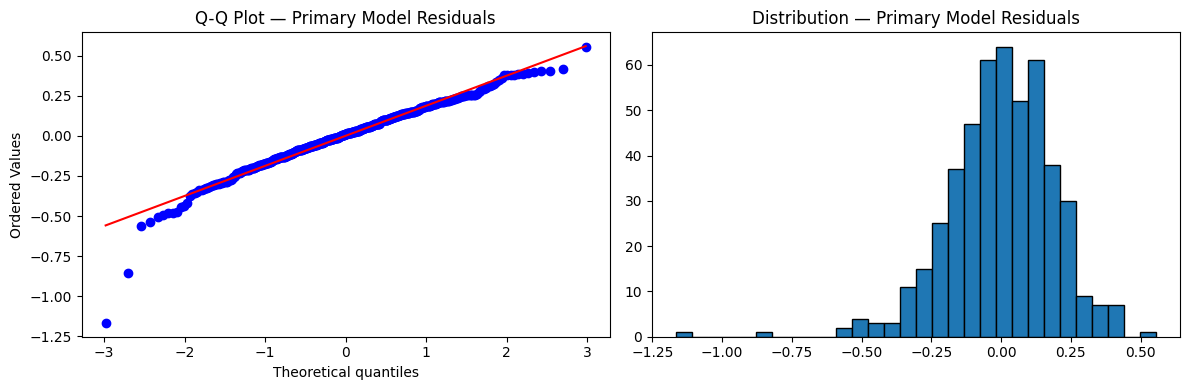

Shapiro-Wilk: W = 0.9662, p = 0.0000


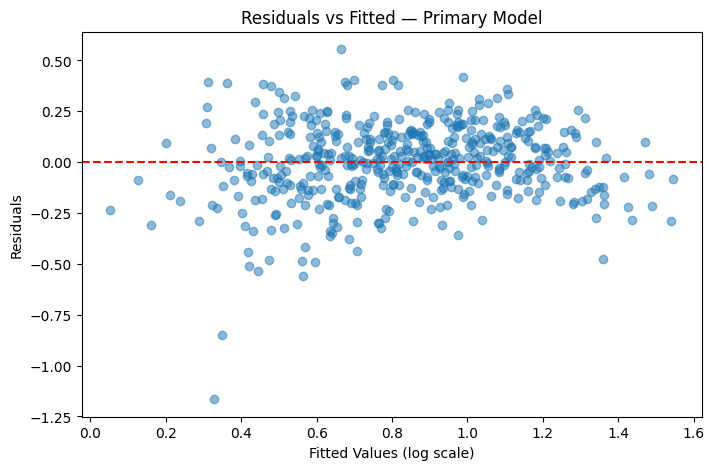

Levene's (Group):        stat=0.000, p=0.9946
Levene's (Visual_Field): stat=2.130, p=0.1451


In [ ]:
print("\n" + "="*80)
print("STEP 6g: ASSUMPTION DIAGNOSTICS — PRIMARY MODEL (interaction, log scale)")
print("="*80)

residuals_primary = model_primary.resid
fitted_primary = model_primary.fittedvalues

# Align rows in case any were dropped due to missing values
rvh_valid = rvh_long_full.loc[residuals_primary.index].copy()
rvh_valid['abs_resid'] = residuals_primary.abs()

# --- 1. Normality ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_primary, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot — Primary Model Residuals')
axes[1].hist(residuals_primary, bins=30, edgecolor='black')
axes[1].set_title('Distribution — Primary Model Residuals')
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals_primary)
print(f"Shapiro-Wilk: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")

# --- 2. Homoscedasticity: residuals vs fitted ---
plt.figure(figsize=(8, 5))
plt.scatter(fitted_primary, residuals_primary, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values (log scale)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted — Primary Model')
plt.show()

# --- 3. Levene's tests: Group and Visual_Field ---
stat_g, p_g = levene(
    rvh_valid.loc[rvh_valid['Group']=='DD', 'abs_resid'],
    rvh_valid.loc[rvh_valid['Group']=='TD', 'abs_resid']
)
stat_vf, p_vf = levene(
    rvh_valid.loc[rvh_valid['Visual_Field']=='Left', 'abs_resid'],
    rvh_valid.loc[rvh_valid['Visual_Field']=='Right', 'abs_resid']
)
print(f"Levene's (Group):        stat={stat_g:.3f}, p={p_g:.4f}")
print(f"Levene's (Visual_Field): stat={stat_vf:.3f}, p={p_vf:.4f}")


In [ ]:
# ================================================================
# STEP 7: LMM models
# ================================================================
print("\n" + "="*80)
print("STEP 7a: CRITICAL MODEL (raw score, with interaction) — full dataset")
print("="*80)

model_primary = smf.mixedlm(
    "Threshold ~ Group * Visual_Field + Run",
    data=rvh_long_full, groups=rvh_long_full["Subject"]
).fit()
print(model_primary.summary())

print("\n" + "="*80)
print("STEP 7b: SENSITIVITY — primary model + Age_centered")
print("="*80)
model_sens_age = smf.mixedlm(
    "Threshold ~ Group * Visual_Field + Run + Age_centered",
    data=rvh_long_full, groups=rvh_long_full["Subject"]
).fit()
print(model_sens_age.summary())

print("\n" + "="*80)
print("STEP 7c: SENSITIVITY — primary model + Accuracy_centered")
print("="*80)

model_sens_acc = smf.mixedlm(
    "Threshold ~ Group * Visual_Field + Run + Accuracy_centered",
    data=rvh_long_full, groups=rvh_long_full["Subject"]
).fit()
print(model_sens_acc.summary())

print("\n" + "="*80)
print("STEP 7d: SENSITIVITY — primary model structure, accuracy-filtered (70-90%) data")
print("="*80)

rvh_long_full['accuracy_in_range'] = rvh_long_full['Accuracy'].between(70, 90)
rvh_filtered = rvh_long_full[rvh_long_full['accuracy_in_range']].copy()

model_sens_filtered = smf.mixedlm(
    "Threshold ~ Group * Visual_Field + Run",
    data=rvh_filtered, groups=rvh_filtered["Subject"]
).fit()
print(model_sens_filtered.summary())


print("\n" + "="*80)
print("STEP 6e: FULL ROBUSTNESS TABLE — comparing interaction term + simple effects")
print("="*80)

def extract_key_terms(model, label):
    return {
        'Model': label,
        'N_obs': int(model.nobs),
        'Group_beta': model.params['Group[T.TD]'],
        'Group_p': model.pvalues['Group[T.TD]'],
        'VF_beta': model.params['Visual_Field[T.Right]'],
        'VF_p': model.pvalues['Visual_Field[T.Right]'],
        'Interaction_beta': model.params['Group[T.TD]:Visual_Field[T.Right]'],
        'Interaction_p': model.pvalues['Group[T.TD]:Visual_Field[T.Right]']
    }

robustness_table = pd.DataFrame([
    extract_key_terms(model_primary, 'Primary (interaction, full N)'),
    extract_key_terms(model_sens_age, '+ Age_centered'),
    extract_key_terms(model_sens_acc, '+ Accuracy_centered'),
    extract_key_terms(model_sens_filtered, 'Accuracy-filtered 70-90%'),
])
print(robustness_table.to_string(index=False))

print("\n" + "="*80)
print("STEP 7f (SECONDARY): Additive main-effects model — for descriptive")
print("marginal effect sizes only, NOT the primary hypothesis test")
print("="*80)

model_additive = smf.mixedlm(
    "Threshold ~ Group + Visual_Field + Run",
    data=rvh_long_full, groups=rvh_long_full["Subject"]
).fit()
print(model_additive.summary())

print("\nComparison: simple effects (primary) vs. marginal main effects (secondary additive):")
print(pd.DataFrame({
    'Primary_simple_effect': [model_primary.params['Group[T.TD]'], model_primary.params['Visual_Field[T.Right]']],
    'Additive_marginal_effect': [model_additive.params['Group[T.TD]'], model_additive.params['Visual_Field[T.Right]']]
}, index=['Group[T.TD]', 'Visual_Field[T.Right]']))


STEP 7a: CRITICAL MODEL (raw score, with interaction) — full dataset
                   Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        Threshold
No. Observations:        479            Method:                    REML     
No. Groups:              80             Scale:                     0.1848   
Min. group size:         3              Log-Likelihood:            -388.2380
Max. group size:         8              Converged:                 Yes      
Mean group size:         6.0                                                
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          3.313    0.130 25.528 0.000  3.059  3.567
Group[T.TD]                       -0.551    0.154 -3.589 0.000 -0.852 -0.250
Visual_Field[T.Right]     


STEP 7g: ASSUMPTION DIAGNOSTICS — PRIMARY MODEL (interaction, log scale)
                   Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        Threshold
No. Observations:        479            Method:                    REML     
No. Groups:              80             Scale:                     0.1848   
Min. group size:         3              Log-Likelihood:            -388.2380
Max. group size:         8              Converged:                 Yes      
Mean group size:         6.0                                                
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          3.313    0.130 25.528 0.000  3.059  3.567
Group[T.TD]                       -0.551    0.154 -3.589 0.000 -0.852 -0.250
Visual_Field[T.Right] 

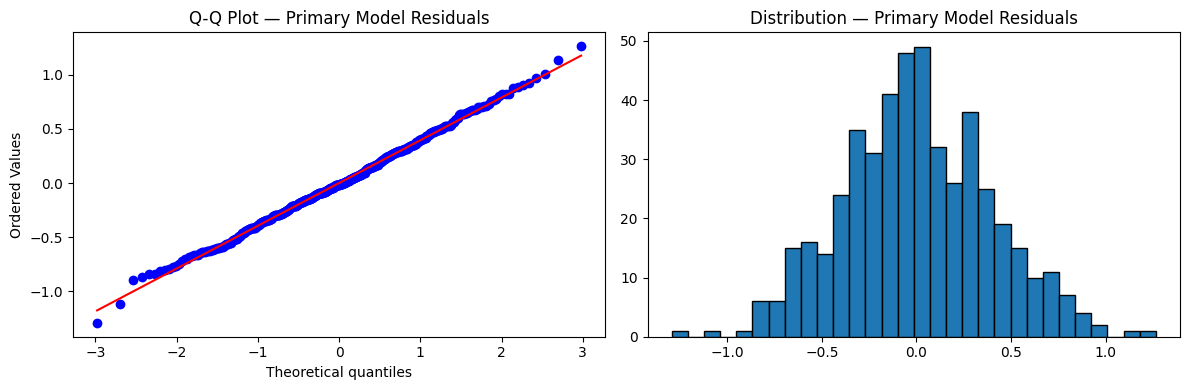

Shapiro-Wilk: W = 0.9981, p = 0.8793


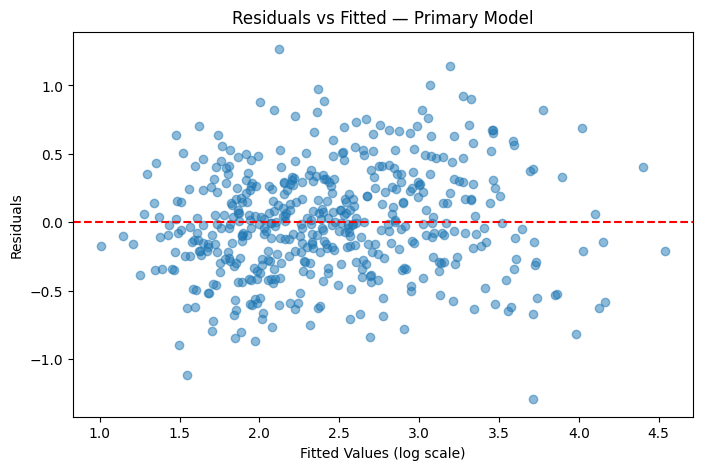

Levene's (Group):        stat=3.748, p=0.0535
Levene's (Visual_Field): stat=0.124, p=0.7254


In [ ]:
print("\n" + "="*80)
print("STEP 7g: ASSUMPTION DIAGNOSTICS — PRIMARY MODEL (interaction, log scale)")
print("="*80)
model_primary = smf.mixedlm(
    "Threshold ~ Group * Visual_Field + Run",
    data=rvh_long_full, groups=rvh_long_full["Subject"]
).fit()
print(model_primary.summary())

residuals_primary = model_primary.resid
fitted_primary = model_primary.fittedvalues

# Align rows in case any were dropped due to missing values
rvh_valid = rvh_long_full.loc[residuals_primary.index].copy()
rvh_valid['abs_resid'] = residuals_primary.abs()

# --- 1. Normality ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(residuals_primary, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot — Primary Model Residuals')
axes[1].hist(residuals_primary, bins=30, edgecolor='black')
axes[1].set_title('Distribution — Primary Model Residuals')
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals_primary)
print(f"Shapiro-Wilk: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")

# --- 2. Homoscedasticity: residuals vs fitted ---
plt.figure(figsize=(8, 5))
plt.scatter(fitted_primary, residuals_primary, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values (log scale)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted — Primary Model')
plt.show()

# --- 3. Levene's tests: Group and Visual_Field ---
stat_g, p_g = levene(
    rvh_valid.loc[rvh_valid['Group']=='DD', 'abs_resid'],
    rvh_valid.loc[rvh_valid['Group']=='TD', 'abs_resid']
)
stat_vf, p_vf = levene(
    rvh_valid.loc[rvh_valid['Visual_Field']=='Left', 'abs_resid'],
    rvh_valid.loc[rvh_valid['Visual_Field']=='Right', 'abs_resid']
)
print(f"Levene's (Group):        stat={stat_g:.3f}, p={p_g:.4f}")
print(f"Levene's (Visual_Field): stat={stat_vf:.3f}, p={p_vf:.4f}")


In [ ]:
# ---- 1. Sex as additive covariate ----
m_sex = smf.mixedlm(
    "Threshold ~ Group * Visual_Field + Run + C(Sex)",
    data=rvh_long_full,
    groups=rvh_long_full["Subject"]
).fit()
print(m_sex.summary())

# ---- 2. Compare against primary model ----
comp = pd.DataFrame({
    'Primary': [model_primary.params['Group[T.TD]'],
                model_primary.params['Visual_Field[T.Right]'],
                model_primary.params['Group[T.TD]:Visual_Field[T.Right]']],
    'Primary_p': [model_primary.pvalues['Group[T.TD]'],
                  model_primary.pvalues['Visual_Field[T.Right]'],
                  model_primary.pvalues['Group[T.TD]:Visual_Field[T.Right]']],
    '+Sex': [m_sex.params['Group[T.TD]'],
             m_sex.params['Visual_Field[T.Right]'],
             m_sex.params['Group[T.TD]:Visual_Field[T.Right]']],
    '+Sex_p': [m_sex.pvalues['Group[T.TD]'],
               m_sex.pvalues['Visual_Field[T.Right]'],
               m_sex.pvalues['Group[T.TD]:Visual_Field[T.Right]']],
}, index=['Group', 'Visual_Field', 'Interaction']).round(4)
print("\n", comp)

print(f"\nSex coefficient: β = {m_sex.params['C(Sex)[T.m]']:.4f}, "
      f"p = {m_sex.pvalues['C(Sex)[T.m]']:.4f}")

# ---- 3. Sex × Visual Field (does asymmetry differ by sex?) ----
m_sex_vf = smf.mixedlm(
    "Threshold ~ Group * Visual_Field + C(Sex) * Visual_Field + Run",
    data=rvh_long_full,
    groups=rvh_long_full["Subject"]
).fit()
print("\n--- Sex × Visual Field ---")
print(m_sex_vf.summary())

# ---- 4. EXPLORATORY three-way (underpowered — smallest cell n≈17) ----
cells = rvh_long_full.drop_duplicates('Subject').groupby(['Group','Sex']).size()
print(f"\nSubjects per Group×Sex cell:\n{cells}")

m_3way = smf.mixedlm(
    "Threshold ~ Group * Visual_Field * C(Sex) + Run",
    data=rvh_long_full,
    groups=rvh_long_full["Subject"]
).fit()
print("\n--- EXPLORATORY three-way ---")
print(f"Group×VF×Sex: β = {m_3way.params['Group[T.TD]:Visual_Field[T.Right]:C(Sex)[T.m]']:.4f}, "
      f"p = {m_3way.pvalues['Group[T.TD]:Visual_Field[T.Right]:C(Sex)[T.m]']:.4f}")


                   Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        Threshold
No. Observations:        479            Method:                    REML     
No. Groups:              80             Scale:                     0.1848   
Min. group size:         3              Log-Likelihood:            -388.7585
Max. group size:         8              Converged:                 Yes      
Mean group size:         6.0                                                
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          3.380    0.147 22.943 0.000  3.091  3.669
Group[T.TD]                       -0.556    0.154 -3.613 0.000 -0.857 -0.254
Visual_Field[T.Right]             -0.386    0.055 -6.988 0.000 -0.494 -0.277
C(Sex)[T.m]        

In [ ]:

# Subject-level mean thresholds, highest first
subj_means = (rvh_long_full.groupby(['Subject', 'Group'])['Threshold']
              .mean().reset_index().sort_values('Threshold', ascending=False))
print("Top 5 highest-threshold participants:")
print(subj_means.head(5).to_string(index=False))

# Reference values from the primary model
ref = {
    'Group':       (model_primary.params['Group[T.TD]'],
                    model_primary.pvalues['Group[T.TD]']),
    'VF':          (model_primary.params['Visual_Field[T.Right]'],
                    model_primary.pvalues['Visual_Field[T.Right]']),
    'Interaction': (model_primary.params['Group[T.TD]:Visual_Field[T.Right]'],
                    model_primary.pvalues['Group[T.TD]:Visual_Field[T.Right]']),
}
print(f"\nPRIMARY (N=80): Group β={ref['Group'][0]:.3f} p={ref['Group'][1]:.4f} | "
      f"VF β={ref['VF'][0]:.3f} p={ref['VF'][1]:.4f} | "
      f"Int β={ref['Interaction'][0]:.3f} p={ref['Interaction'][1]:.4f}")

# Leave-one-out for the top 3
rows = []
for sid in subj_means['Subject'].head(3):
    d = rvh_long_full[rvh_long_full.Subject != sid]
    m = smf.mixedlm("Threshold ~ Group * Visual_Field + Run",
                    data=d, groups=d["Subject"]).fit()
    rows.append({
        'Excluded': sid,
        'Group_β': round(m.params['Group[T.TD]'], 3),
        'Group_p': round(m.pvalues['Group[T.TD]'], 4),
        'VF_β': round(m.params['Visual_Field[T.Right]'], 3),
        'VF_p': round(m.pvalues['Visual_Field[T.Right]'], 4),
        'Int_β': round(m.params['Group[T.TD]:Visual_Field[T.Right]'], 3),
        'Int_p': round(m.pvalues['Group[T.TD]:Visual_Field[T.Right]'], 4),
    })
print("\nLeave-one-out results:")
print(pd.DataFrame(rows).to_string(index=False))


Top 5 highest-threshold participants:
Subject Group  Threshold
   DD11    DD   4.461558
   DD42    DD   3.920366
   DD36    DD   3.824141
   DD41    DD   3.736074
   DD18    DD   3.654509

PRIMARY (N=80): Group β=-0.551 p=0.0003 | VF β=-0.386 p=0.0000 | Int β=0.141 p=0.0724

Leave-one-out results:
Excluded  Group_β  Group_p   VF_β  VF_p  Int_β  Int_p
    DD11   -0.509   0.0006 -0.388   0.0  0.144 0.0679
    DD42   -0.527   0.0005 -0.398   0.0  0.153 0.0523
    DD36   -0.522   0.0006 -0.382   0.0  0.138 0.0794


In [ ]:
loo = []
for sid in rvh_long_full['Subject'].unique():
    d = rvh_long_full[rvh_long_full.Subject != sid]
    m = smf.mixedlm("Threshold ~ Group * Visual_Field + Run",
                    data=d, groups=d["Subject"]).fit()
    loo.append({
        'Subject': sid,
        'Int_β': m.params['Group[T.TD]:Visual_Field[T.Right]'],
        'Int_p': m.pvalues['Group[T.TD]:Visual_Field[T.Right]'],
        'Group_p': m.pvalues['Group[T.TD]'],
    })
loo_df = pd.DataFrame(loo)

print(f"Interaction p across all leave-one-out fits: "
      f"min={loo_df.Int_p.min():.4f}, max={loo_df.Int_p.max():.4f}, "
      f"median={loo_df.Int_p.median():.4f}")
print(f"Group p stays significant in "
      f"{(loo_df.Group_p < .05).sum()}/{len(loo_df)} fits")

print("\nParticipants whose removal pushes interaction below p<.05:")
print(loo_df[loo_df.Int_p < .05].to_string(index=False))

print("\n5 most influential on the interaction (largest |Δβ|):")
loo_df['delta'] = (loo_df.Int_β - ref['Interaction'][0]).abs()
print(loo_df.nlargest(5, 'delta')[['Subject','Int_β','Int_p','delta']].to_string(index=False))


Interaction p across all leave-one-out fits: min=0.0247, max=0.1573, median=0.0748
Group p stays significant in 80/80 fits

Participants whose removal pushes interaction below p<.05:
Subject    Int_β    Int_p  Group_p
   DD12 0.156282 0.049156 0.000458
   DD28 0.155977 0.047792 0.000189
   DD39 0.173643 0.024742 0.000362
   DD41 0.161383 0.039237 0.000478
   DD44 0.164576 0.036807 0.000191
   DD46 0.155642 0.049088 0.000300
   TD09 0.164576 0.036437 0.000376
   TD10 0.163675 0.037751 0.000144
   TD28 0.160304 0.042390 0.000287
   TD36 0.158684 0.043216 0.000409

5 most influential on the interaction (largest |Δβ|):
Subject    Int_β    Int_p    delta
   DD39 0.173643 0.024742 0.032452
   DD27 0.110399 0.157322 0.030793
   TD22 0.116751 0.138422 0.024441
   TD45 0.117227 0.137115 0.023964
   DD44 0.164576 0.036807 0.023385


In [ ]:
asym = (rvh_long_full.groupby(['Subject','Group','Visual_Field'])['Threshold']
        .mean().reset_index()
        .pivot_table(index=['Subject','Group'], columns='Visual_Field',
                     values='Threshold').reset_index())
asym['RVF_advantage'] = asym['Left'] - asym['Right']

print(asym.groupby('Group')['RVF_advantage'].agg(['mean','std','count']).round(3))

# Proportion showing the advantage at all
print("\nProportion with RVF advantage > 0:")
print(asym.groupby('Group')['RVF_advantage'].apply(lambda x: (x > 0).mean()).round(3))


        mean    std  count
Group                     
DD     0.405  0.517     41
TD     0.253  0.476     39

Proportion with RVF advantage > 0:
Group
DD    0.805
TD    0.667
Name: RVF_advantage, dtype: float64


# Visuals

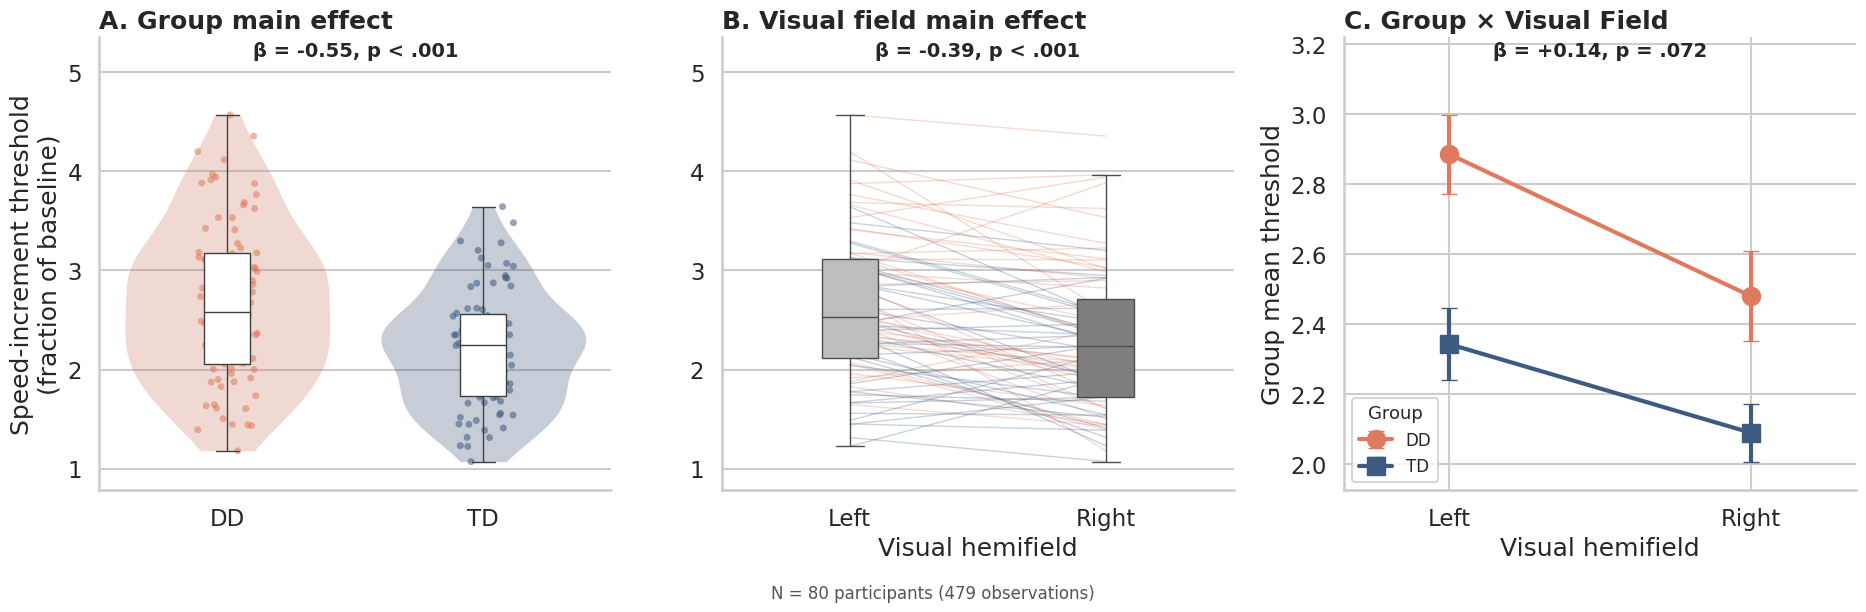

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid"); sns.set_context("talk")
PAL = {'DD': '#E07A5F', 'TD': '#3D5A80'}

DATA = rvh_long_full          # <-- point at your current dataframe
MODEL = model_primary     # <-- point at your current fitted model

# ---- Pull stats from the model so they can't drift out of sync ----
b_g,  p_g  = MODEL.params['Group[T.TD]'],           MODEL.pvalues['Group[T.TD]']
b_vf, p_vf = MODEL.params['Visual_Field[T.Right]'], MODEL.pvalues['Visual_Field[T.Right]']
b_i,  p_i  = (MODEL.params['Group[T.TD]:Visual_Field[T.Right]'],
              MODEL.pvalues['Group[T.TD]:Visual_Field[T.Right]'])

def fmt(b, p):
    ptxt = "p < .001" if p < .001 else f"p = {p:.3f}".replace("0.", ".")
    return f"β = {b:+.2f}, {ptxt}"

subj = DATA.groupby(['Subject','Group','Visual_Field'])['Threshold'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))

# ---------- A: Group main effect ----------
sns.violinplot(data=subj, x='Group', y='Threshold', ax=axes[0], hue='Group',
               palette=PAL, inner=None, cut=0, alpha=0.30, linewidth=0, legend=False)
sns.boxplot(data=subj, x='Group', y='Threshold', ax=axes[0], width=0.18,
            boxprops={'facecolor':'white','zorder':3}, showfliers=False,
            whiskerprops={'zorder':3}, zorder=3)
sns.stripplot(data=subj, x='Group', y='Threshold', ax=axes[0], hue='Group',
              palette=PAL, alpha=0.55, size=5, jitter=0.12, zorder=2, legend=False)
axes[0].set_title('A. Group main effect', loc='left', fontweight='bold')
axes[0].set_ylabel('Speed-increment threshold\n(fraction of baseline)')
axes[0].set_xlabel('')

# ---------- B: Visual field main effect ----------
wide = subj.pivot_table(index=['Subject','Group'], columns='Visual_Field',
                        values='Threshold').reset_index()
for _, r in wide.iterrows():
    axes[1].plot([0,1], [r['Left'], r['Right']], color=PAL[r['Group']],
                 alpha=0.28, linewidth=1, zorder=1)
sns.boxplot(data=subj, x='Visual_Field', y='Threshold', order=['Left','Right'],
            ax=axes[1], width=0.22, hue='Visual_Field',
            palette=['#BDBDBD','#7E7E7E'], showfliers=False, zorder=3, legend=False)
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Left','Right'])
axes[1].set_title('B. Visual field main effect', loc='left', fontweight='bold')
axes[1].set_xlabel('Visual hemifield'); axes[1].set_ylabel('')

# ---------- C: Interaction ----------
summ = subj.groupby(['Group','Visual_Field'])['Threshold'].agg(['mean','sem']).reset_index()
for g, mk in [('DD','o'), ('TD','s')]:
    s = summ[summ.Group==g].set_index('Visual_Field').reindex(['Left','Right'])
    axes[2].errorbar([0,1], s['mean'], yerr=s['sem'], marker=mk, markersize=13,
                     linewidth=3, capsize=6, color=PAL[g], label=g, zorder=3)
axes[2].set_xticks([0,1]); axes[2].set_xticklabels(['Left','Right'])
axes[2].set_xlim(-0.35, 1.35)
axes[2].set_title('C. Group × Visual Field', loc='left', fontweight='bold')
axes[2].set_xlabel('Visual hemifield')
axes[2].set_ylabel('Group mean threshold')
axes[2].legend(title='Group', frameon=True, loc='lower left',
               fontsize=12, title_fontsize=13)

# ---------- Headroom + annotate ONCE ----------
for ax in axes:
    lo, hi = ax.get_ylim(); rng = hi - lo
    ax.set_ylim(lo - 0.03*rng, hi + 0.16*rng)
    ax.spines[['top','right']].set_visible(False)

for ax, txt in zip(axes, [fmt(b_g, p_g), fmt(b_vf, p_vf), fmt(b_i, p_i)]):
    ax.text(0.5, 0.99, txt, transform=ax.transAxes, ha='center', va='top',
            fontsize=14, fontweight='bold')

fig.suptitle(f"N = {DATA['Subject'].nunique()} participants "
             f"({int(MODEL.nobs)} observations)",
             y=0.005, fontsize=12, color='#555555')

plt.tight_layout()
plt.savefig('poster_results.png', dpi=300, bbox_inches='tight',
            facecolor='white', pad_inches=0.3)
plt.show()


In [ ]:
rows = []
for var in ['Age','IQ','nvIQ','vIQ']:
    dd = subject_demo.loc[subject_demo.Group=='DD', var].dropna()
    td = subject_demo.loc[subject_demo.Group=='TD', var].dropna()
    u, p = stats.mannwhitneyu(dd, td)
    rows.append({'Measure': var,
                 'DD (n=41)': f"{dd.mean():.1f} ± {dd.std():.1f}",
                 'TD (n=39)': f"{td.mean():.1f} ± {td.std():.1f}",
                 'p': f"{p:.3f}"})
sex = pd.crosstab(subject_demo.Group, subject_demo.Sex)
_, p_sex, _, _ = stats.chi2_contingency(sex)
rows.append({'Measure':'Sex (f/m)',
             'DD (n=41)': f"{sex.loc['DD','f']}/{sex.loc['DD','m']}",
             'TD (n=39)': f"{sex.loc['TD','f']}/{sex.loc['TD','m']}",
             'p': f"{p_sex:.3f}"})
print(pd.DataFrame(rows).to_string(index=False))


  Measure    DD (n=41)    TD (n=39)     p
      Age   26.4 ± 7.0   30.0 ± 8.6 0.040
       IQ 102.6 ± 11.5 109.6 ± 13.3 0.021
     nvIQ 108.5 ± 12.0 108.6 ± 13.7 0.901
      vIQ 103.3 ± 11.2 110.6 ± 10.2 0.005
Sex (f/m)        22/19        22/17 0.982
